# <center>Problem Statement</center>

The goal of this project is to analyze the factors that influence life expectancy across different countries and years using data collected by the World Health Organization (WHO). Life expectancy is an important indicator of a country's overall health and development, and it is influenced by multiple factors such as healthcare expenditure, vaccination coverage, economic conditions, education, and disease prevalence.

In this project, we aim to build a machine learning regression model to predict life expectancy based on various socioeconomic, health, and demographic indicators. Additionally, exploratory data analysis (EDA) will be performed to understand the relationships between these factors and life expectancy.

The insights obtained from this analysis can help identify the key determinants that contribute to higher or lower life expectancy across countries.

# <center>Data Overview</center>


The dataset contains global health and socioeconomic indicators for multiple countries over the years 2000 to 2015. It includes information related to mortality rates, vaccination coverage, economic indicators, healthcare expenditure, and education levels.

The dataset consists of 2938 observations and 21 features, where each row represents the data for a specific country in a particular year.

The target variable for this project is Life expectancy, which represents the average number of years a person is expected to live in a given country.

The features in the dataset include variables such as:

- Adult mortality rates

- Infant and underfive deaths

- Vaccination coverage (Hepatitis B, Polio, Diphtheria)

- Economic indicators such as GDP

- Health expenditure

- Education levels (schooling)

- Population statistics

- Diseaserelated indicators such as HIV/AIDS

These variables collectively help explain the differences in life expectancy across countries and over time.

# <center>Data Dictionary</center>

| Column                          | Description                                                       |
|---------------------------------|-------------------------------------------------------------------|
| Country                         | Name of the country                                              |
| Year                            | Year of the record                                               |
| Status                          | Whether the country is developing or developed                   |
| Life expectancy                 | Average life expectancy of people in that country                |
| Adult Mortality                 | Probability of dying between ages 15 and 60 (per 1000 population)|
| infant deaths                   | Number of infant deaths per 1000 population                      |
| Alcohol                         | Alcohol consumption per capita                                   |
| percentage expenditure          | Health expenditure as percentage of GDP per capita               |
| Hepatitis B                     | Hepatitis B vaccination coverage among children (%)              |
| Measles                         | Number of reported measles cases                                 |
| BMI                             | Average Body Mass Index of the population                        |
| under-five deaths               | Number of deaths of children under 5 years                       |
| Polio                           | Polio vaccination coverage (%)                                   |
| Total expenditure               | Government expenditure on health                                 |
| Diphtheria                      | Diphtheria vaccination coverage (%)                              |
| HIV/AIDS                        | Death rate due to HIV/AIDS                                       |
| GDP                             | Gross Domestic Product per capita                                |
| Population                      | Population of the country                                        |
| thinness 1-19 years             | Prevalence of thinness among children and adolescents            |
| thinness 5-9 years              | Prevalence of thinness among children aged 5–9                   |
| Income composition of resources | Human development index indicator                                |
| Schooling                       | Average years of schooling                                       |

# <Center>Data Loading</center>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

In [3]:
# Importing the dataset
df = pd.read_csv("Life Expectancy Data.csv")

In [4]:
# Checking first five rows
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [5]:
# Checking the shape of dataset
df.shape

(2938, 22)

# <center>Data Understanding </center>

In [6]:
# Checking the summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [7]:
# Checking the dtypes of columns
df.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [8]:
# Checking the statistical summary of numerical columns
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [9]:
# Checking the statistical summary of categorical variables
df.describe(exclude='number')

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [10]:
# Checking the column names
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [11]:
# Checking the null values in columns
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [ ]:
# Cleaning the column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(" ", "_")
    .str.replace("/", "_")
    .str.replace("", "_")
)
df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_1_19_years',
       'thinness_5_9_years', 'income_composition_of_resources', 'schooling'],
      dtype='object')

In [13]:
# Dropping the rows where target variable i.e. life_expectancy isnull.
df = df.dropna(subset=['life_expectancy'])

In [14]:
# Checking the null values using heatmap
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cmap='magma')
plt.plot()

[]

In [15]:
# Checking for duplicate records
df.duplicated().sum()

np.int64(0)

In [16]:
# Creating a list of num_cols and cat_cols
num_cols = df.select_dtypes(include='number').columns.to_list()
cat_cols = df.select_dtypes(exclude='number').columns.to_list()
print(f"Total Numerical columns we have {len(num_cols)} i.e. {num_cols}")
print(f"Total Categorical columns we have {len(cat_cols)} i.e. {cat_cols}")

Total Numerical columns we have 20 i.e. ['year', 'life_expectancy', 'adult_mortality', 'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure', 'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_1_19_years', 'thinness_5_9_years', 'income_composition_of_resources', 'schooling']
Total Categorical columns we have 2 i.e. ['country', 'status']


# <center>Univariate Analysis</center>

In [ ]:
# Checking the unique categories in categorical columns
for col in cat_cols:
    print('--------------------------------------------')
    print(f'Column: {col}')
    print(f'Number of unique values: {df[col].nunique()}')
    print(df[col].value_counts().head(10))
print('--------------------------------------------')
    

--------------------------------------------
Column: country
Number of unique values: 183
country
Afghanistan            16
Albania                16
Algeria                16
Angola                 16
Antigua and Barbuda    16
Argentina              16
Armenia                16
Australia              16
Austria                16
Azerbaijan             16
Name: count, dtype: int64
--------------------------------------------
Column: status
Number of unique values: 2
status
Developing    2416
Developed      512
Name: count, dtype: int64
--------------------------------------------


In [18]:
# Droping the country column due to high cardinality
df.drop('country', axis =1, inplace=True)

In [19]:
#Again Updating the list of cat_cols
cat_cols = df.select_dtypes(exclude='number').columns.to_list()

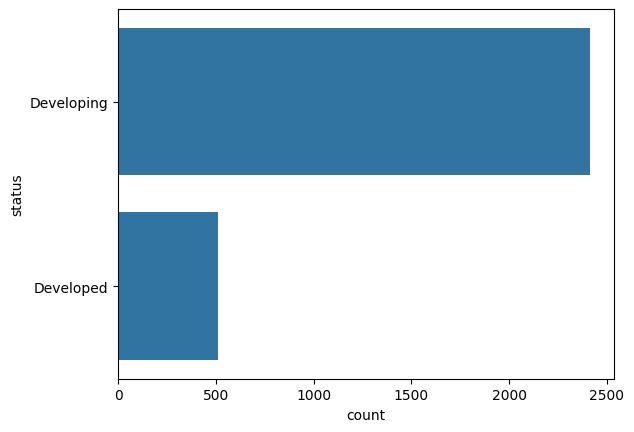

In [210]:
# Checking the countplot of categorical variables
for col in cat_cols:
    sns.countplot(df[col])
    plt.show()

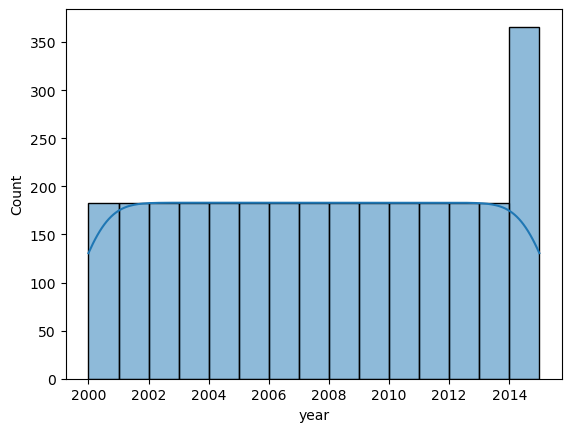

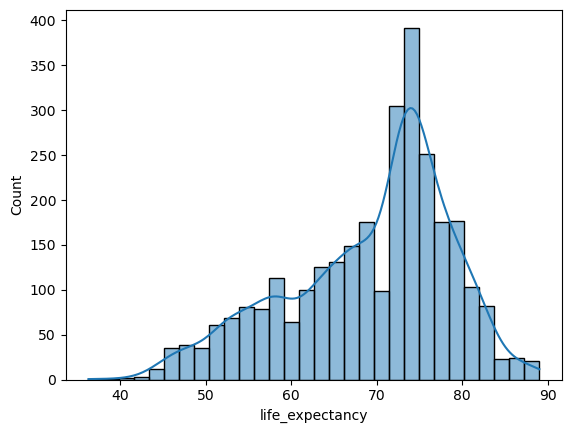

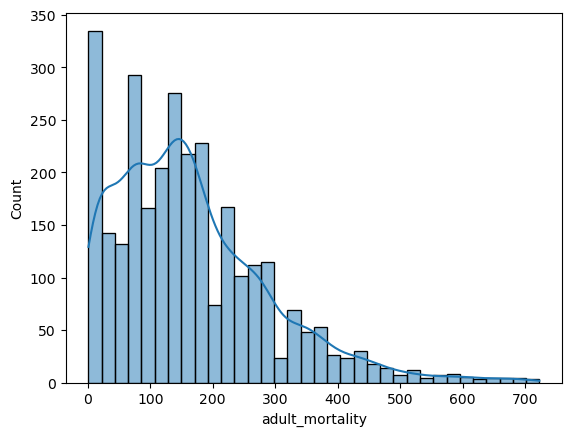

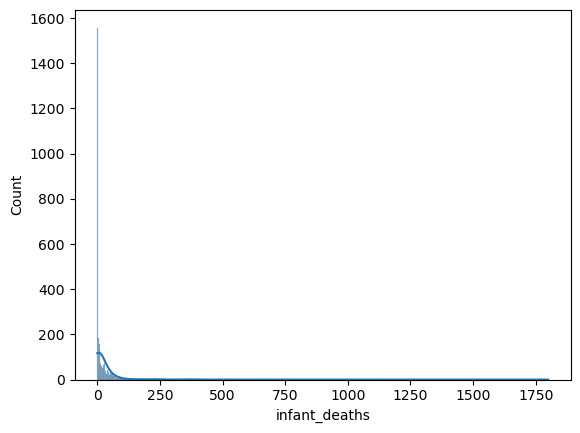

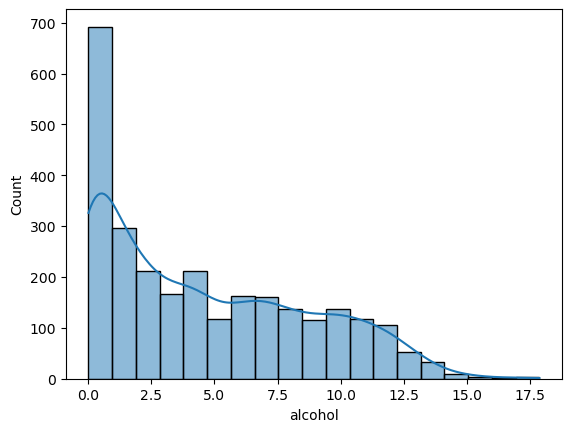

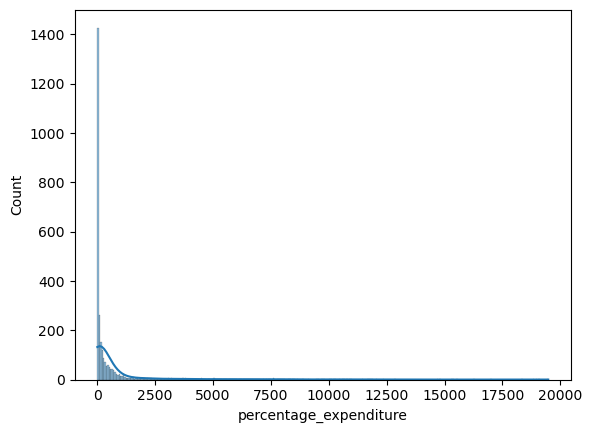

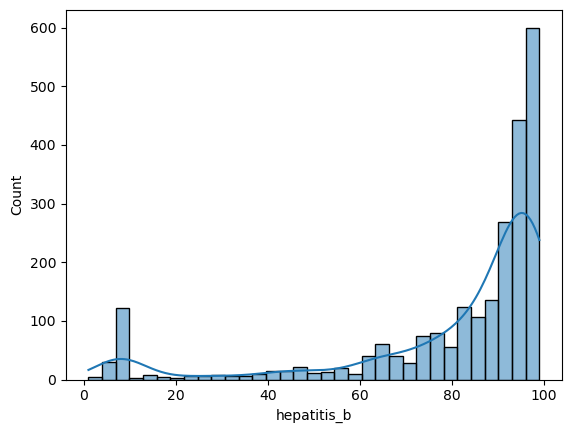

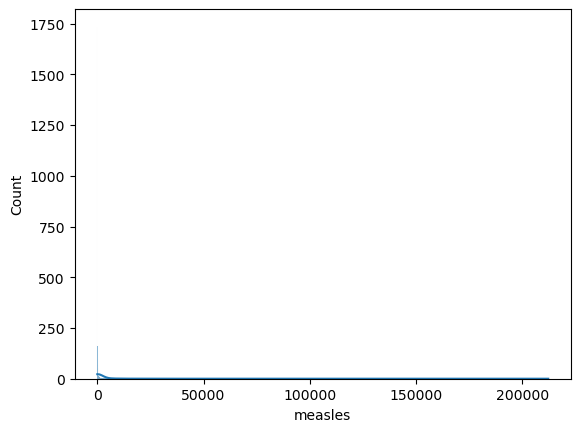

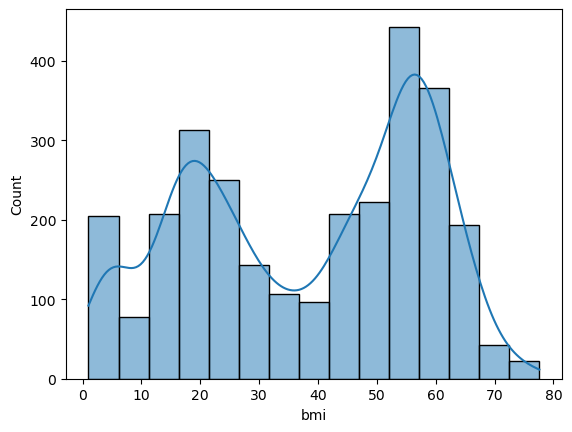

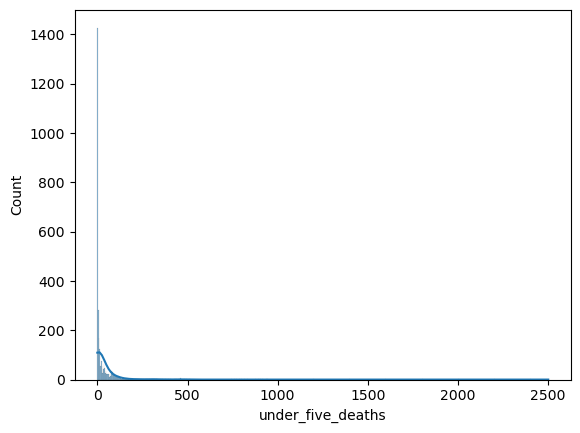

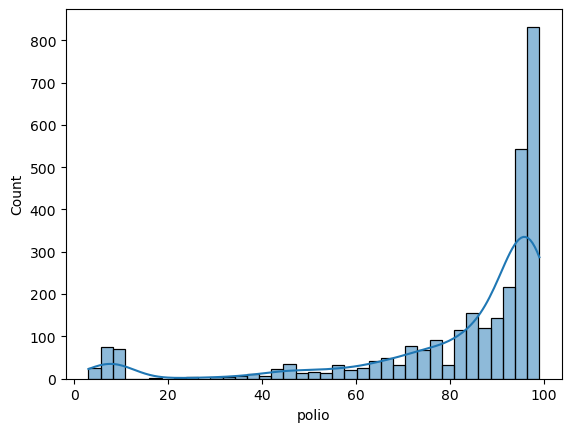

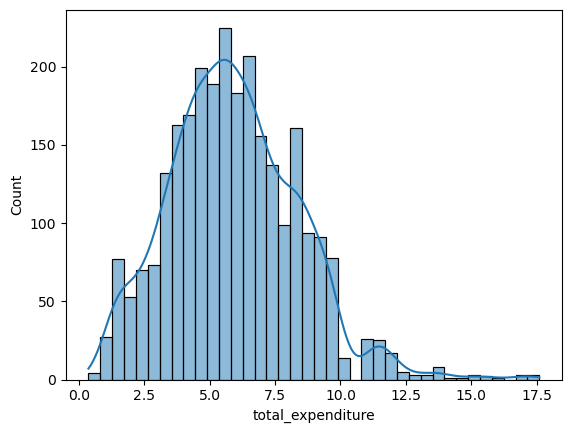

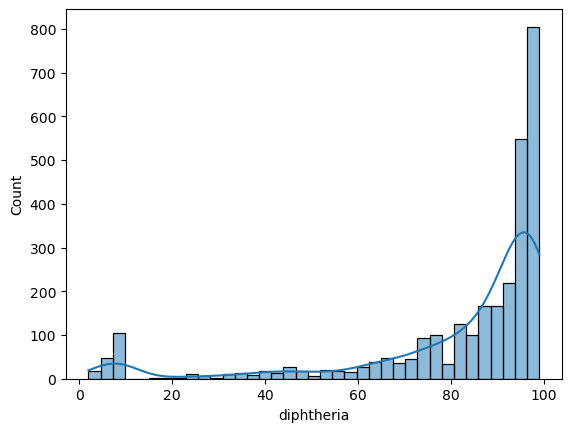

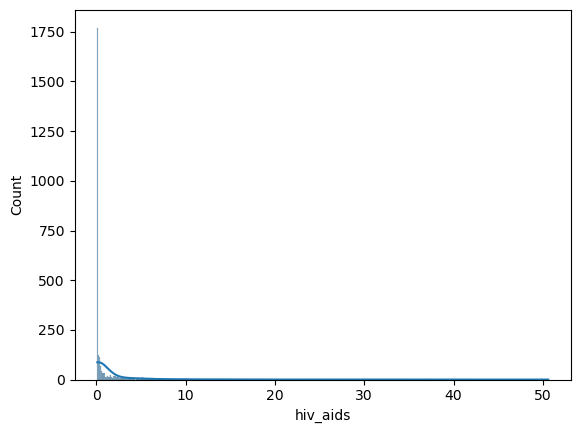

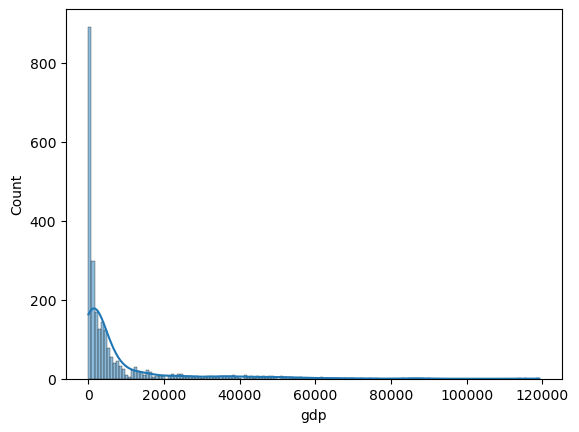

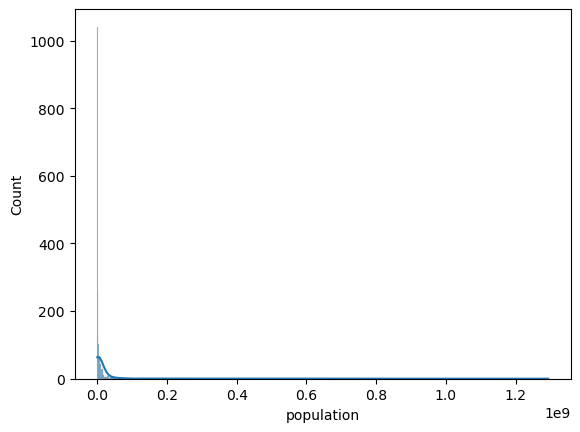

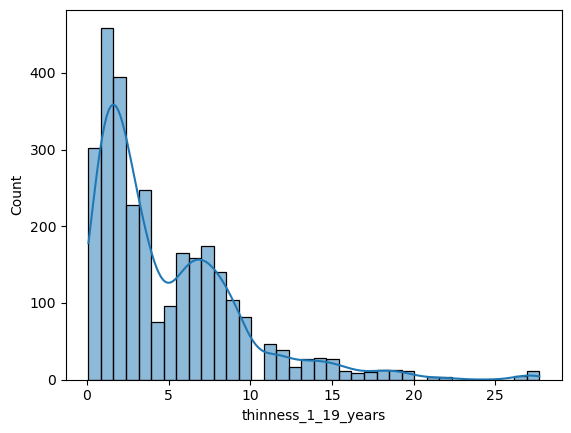

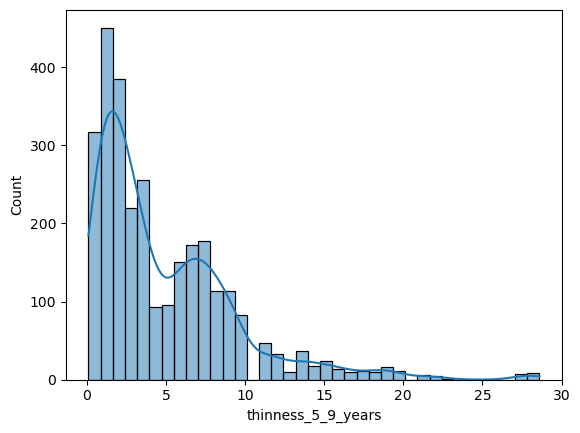

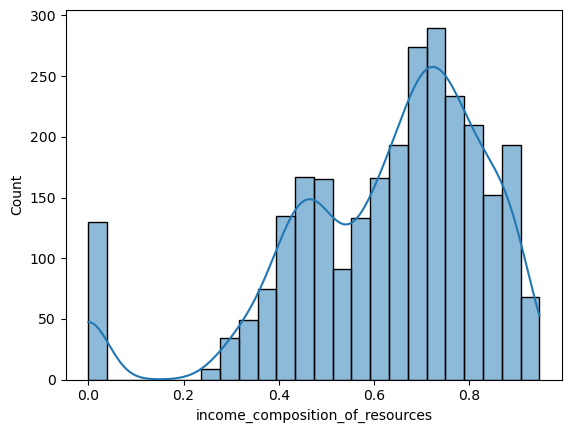

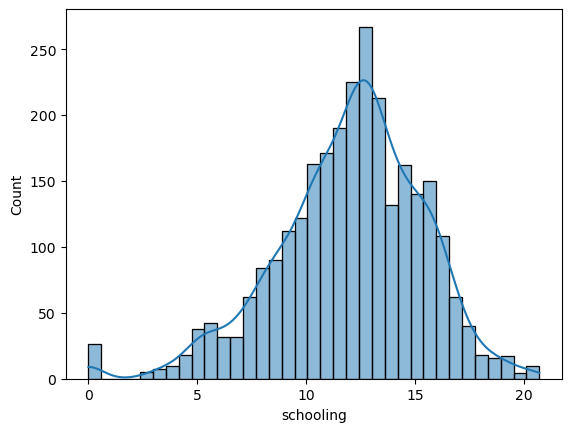

In [21]:
# Checking the distribution of numerical variables
for col in num_cols:
    sns.histplot(df[col],kde=True)
    plt.show()

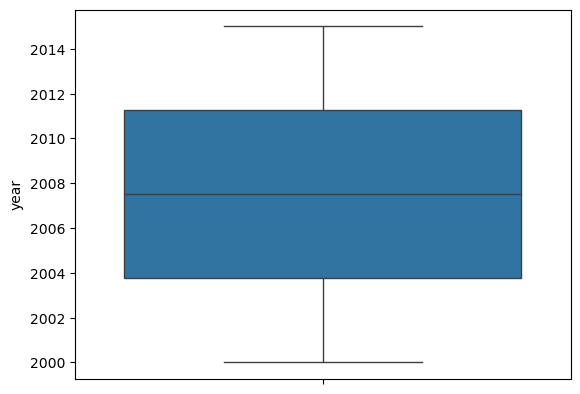

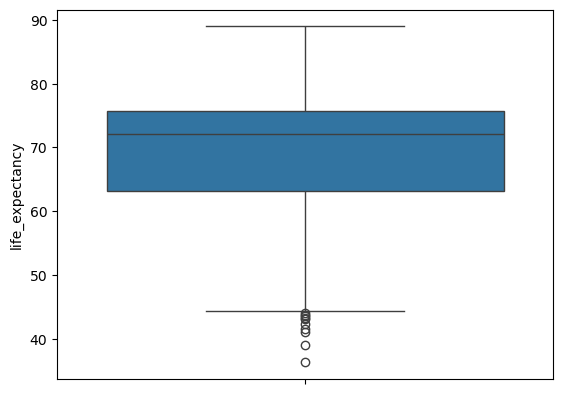

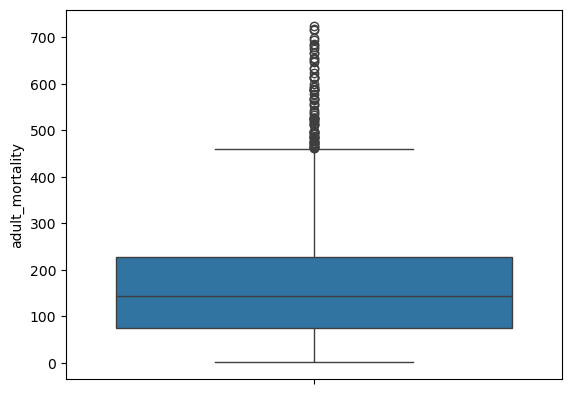

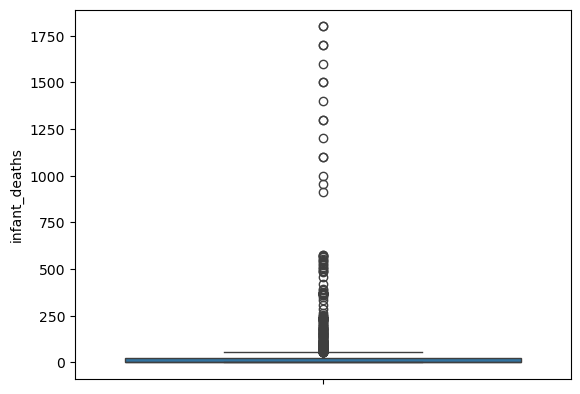

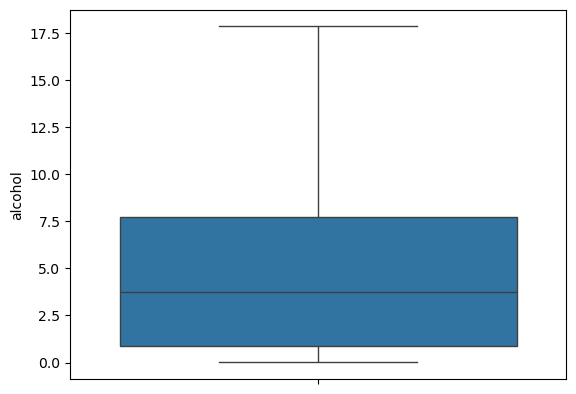

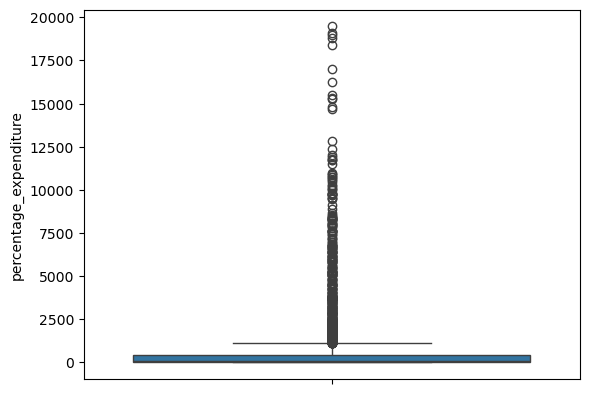

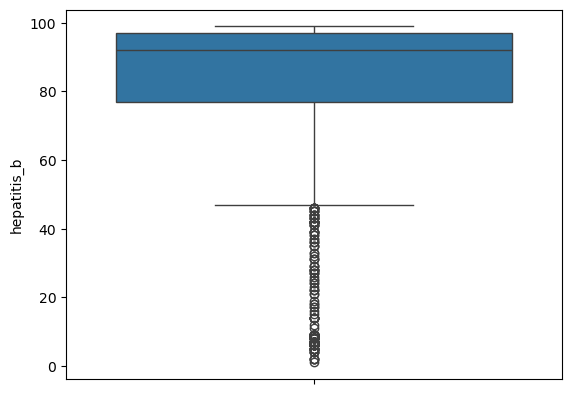

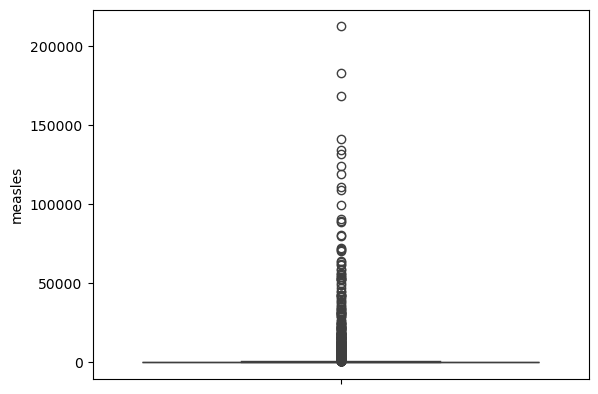

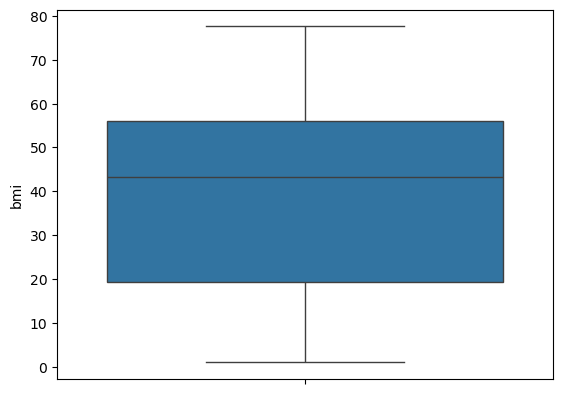

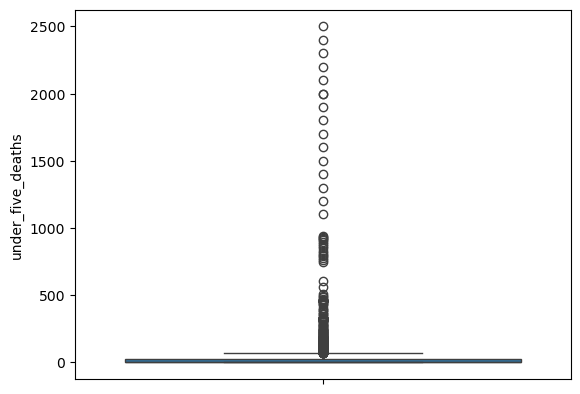

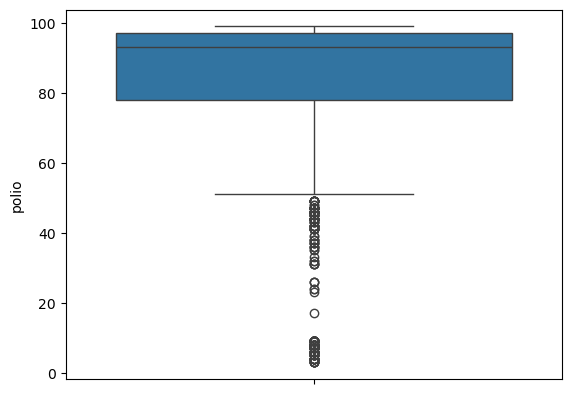

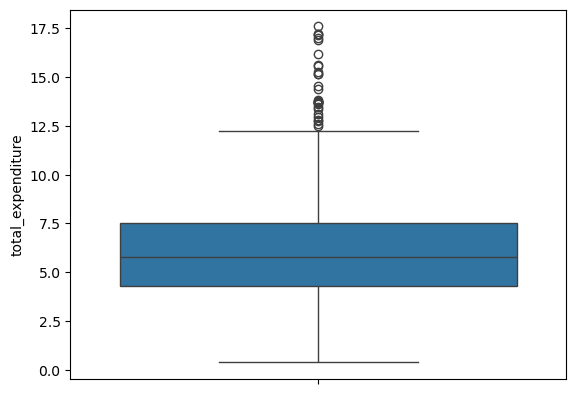

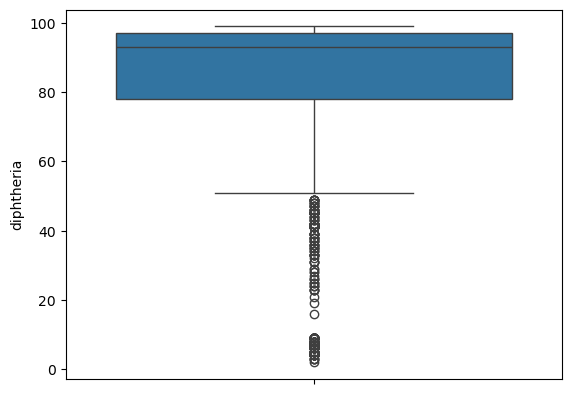

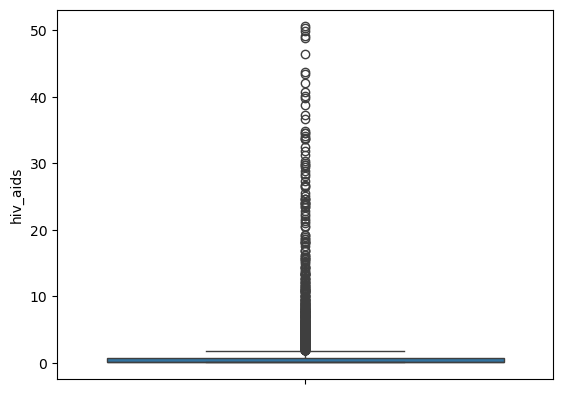

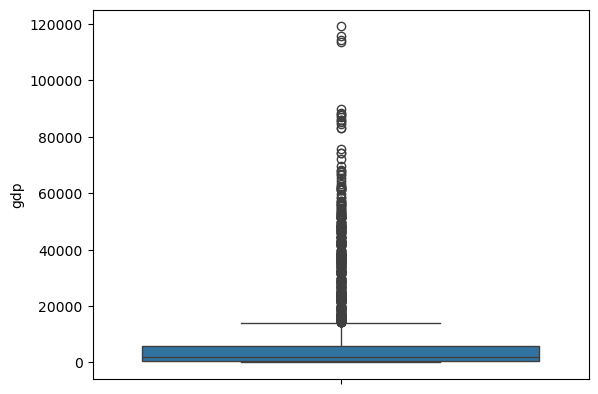

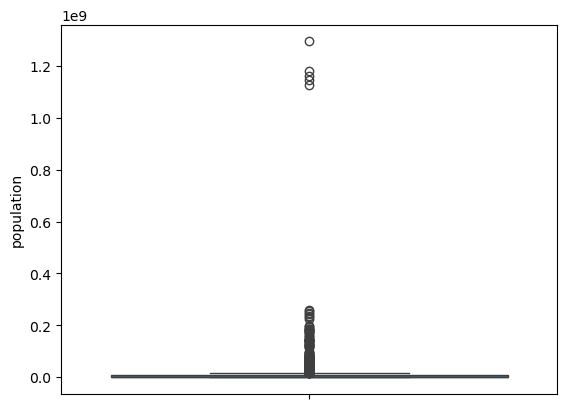

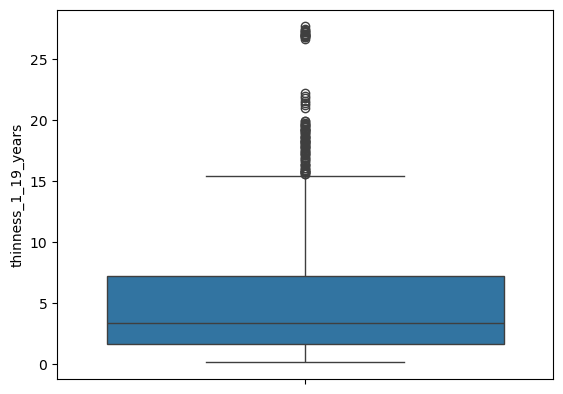

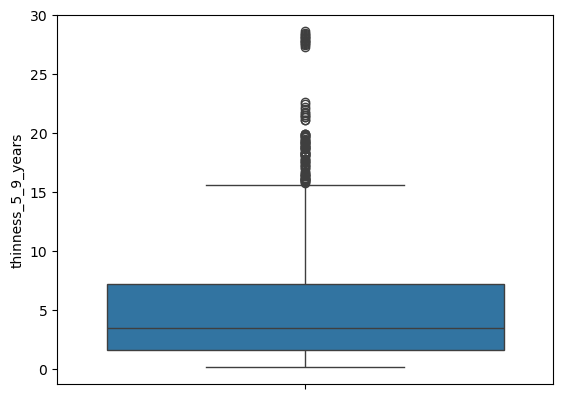

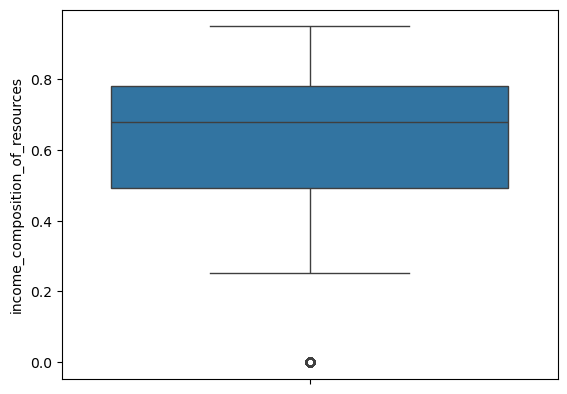

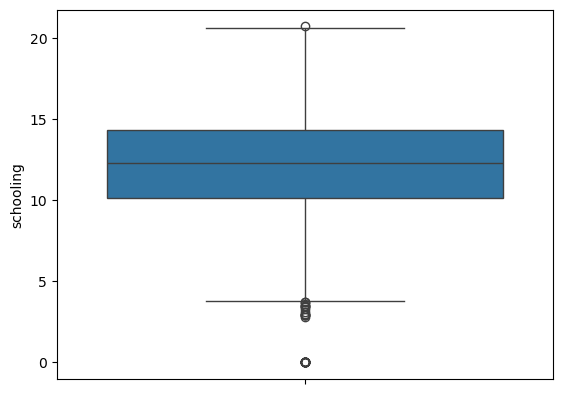

In [22]:
# Checking the outliers using Box plot
for col in num_cols:
    sns.boxplot(df[col])
    plt.show()

In [23]:
# Checking the skewness of numerical cols
df[num_cols].skew().sort_values(ascending=False)

population                         15.909653
infant_deaths                       9.771044
under_five_deaths                   9.479623
measles                             9.425290
hiv_aids                            5.386623
percentage_expenditure              4.643790
gdp                                 3.202781
thinness_5_9_years                  1.776591
thinness_1_19_years                 1.710626
adult_mortality                     1.174369
alcohol                             0.587276
total_expenditure                   0.577233
year                                0.000000
bmi                                -0.230559
schooling                          -0.583884
life_expectancy                    -0.638605
income_composition_of_resources    -1.142142
hepatitis_b                        -1.933774
diphtheria                         -2.072601
polio                              -2.097958
dtype: float64

# <center>Bivariate Analysis</center>

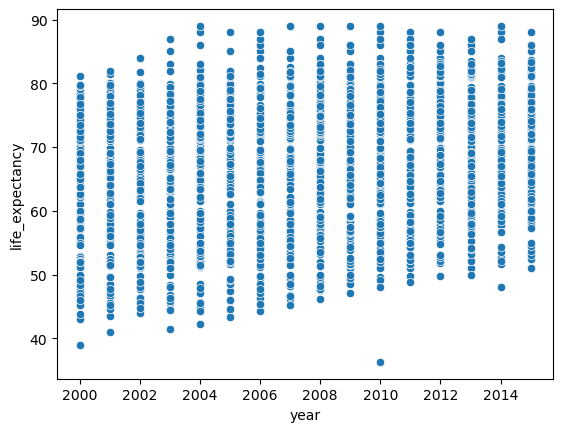

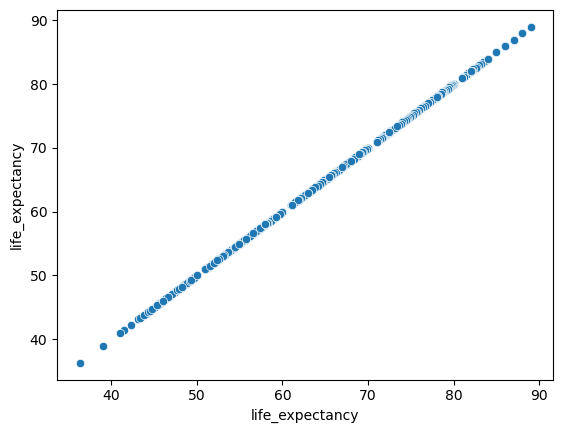

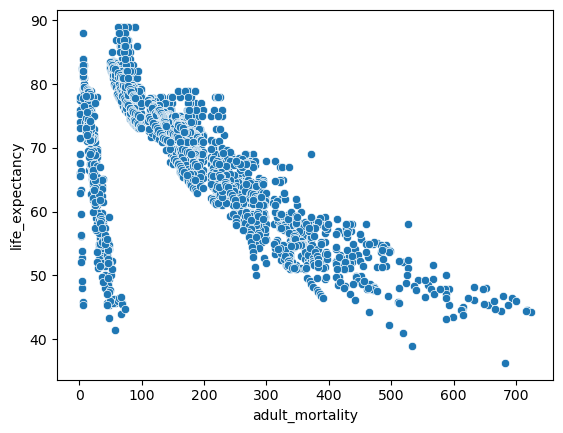

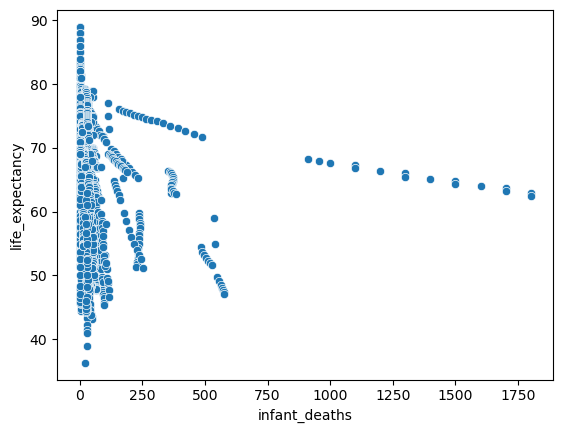

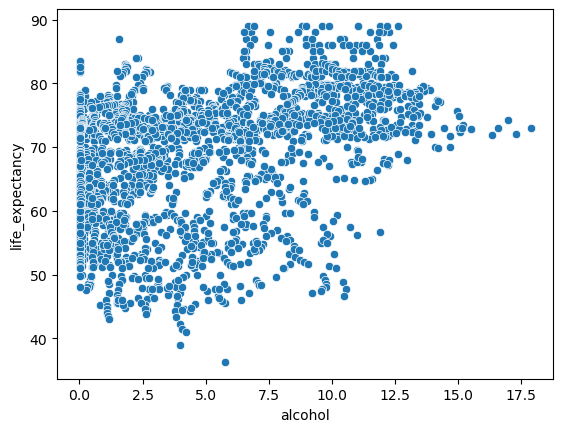

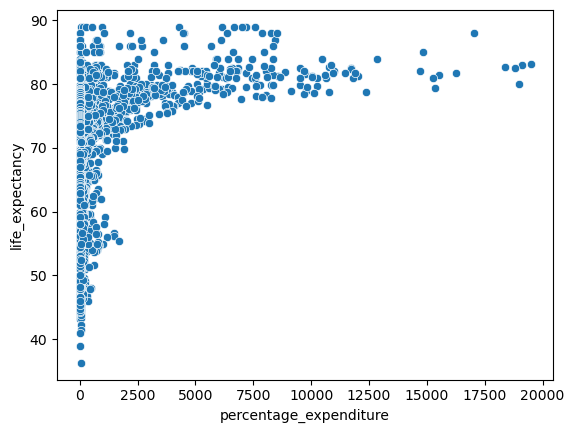

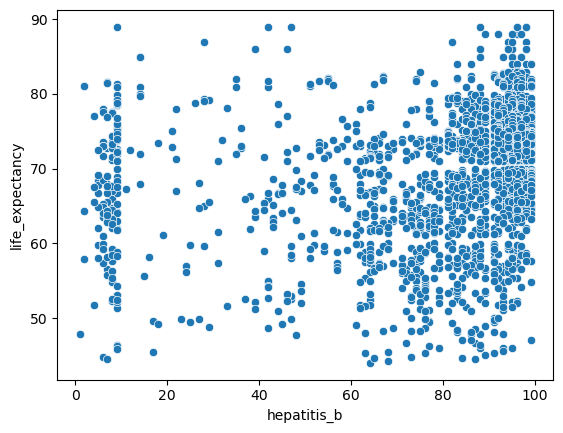

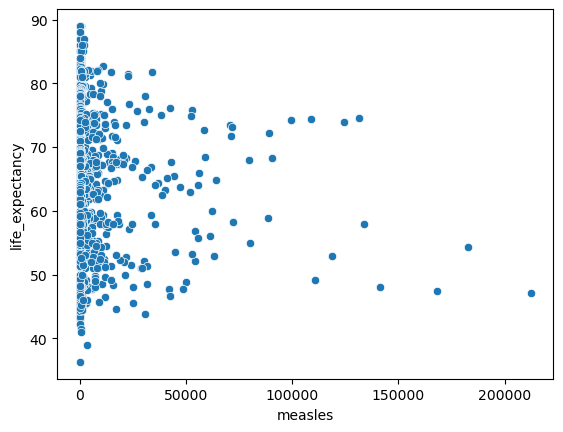

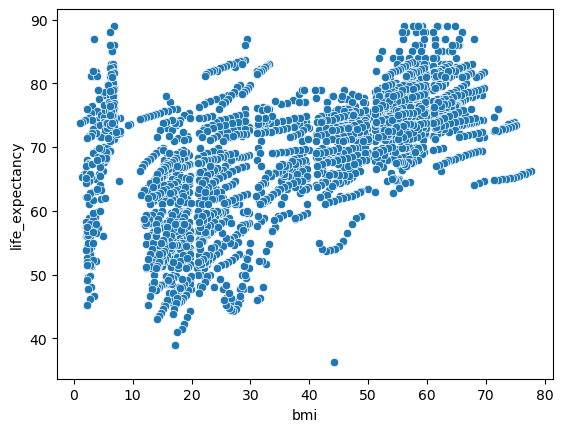

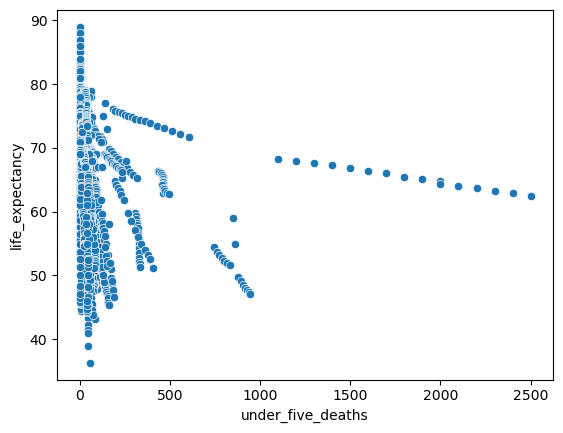

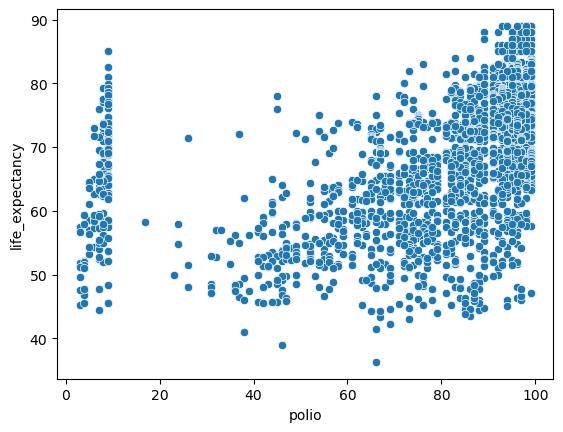

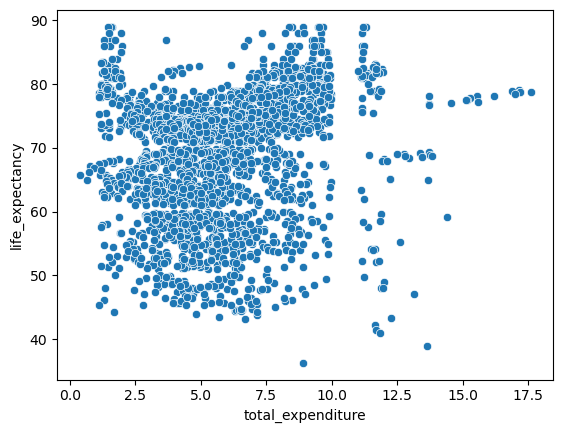

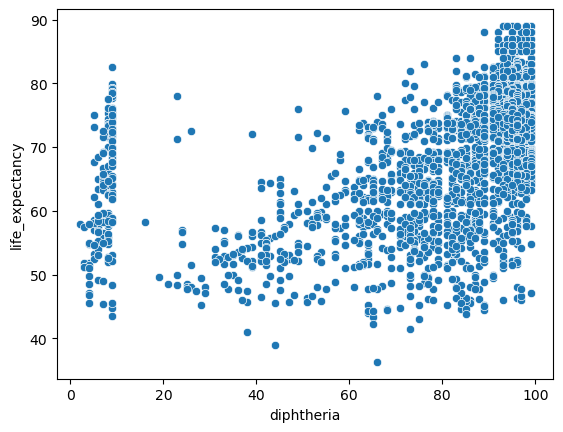

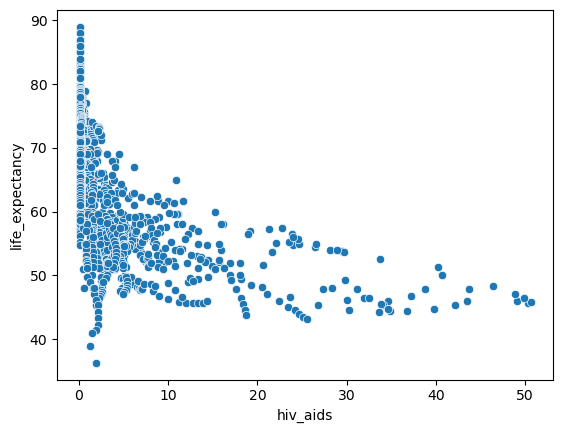

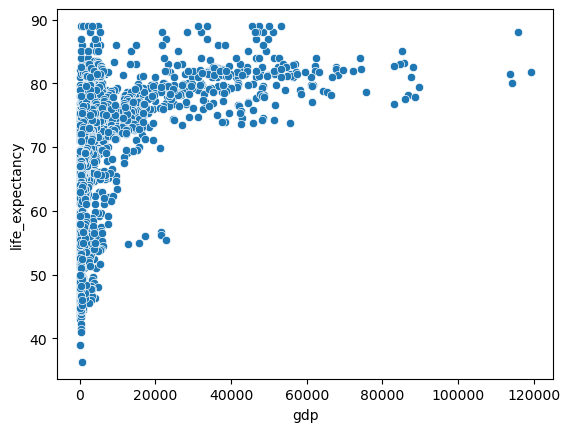

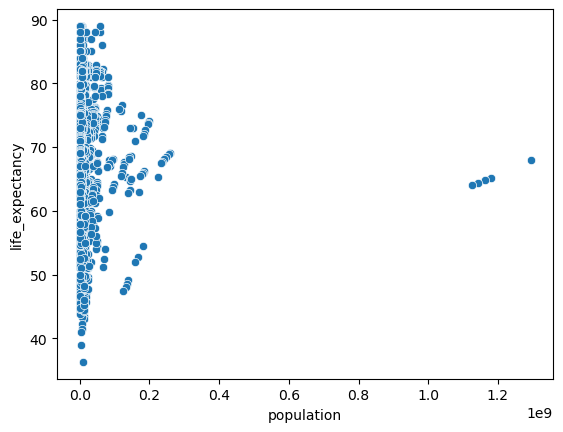

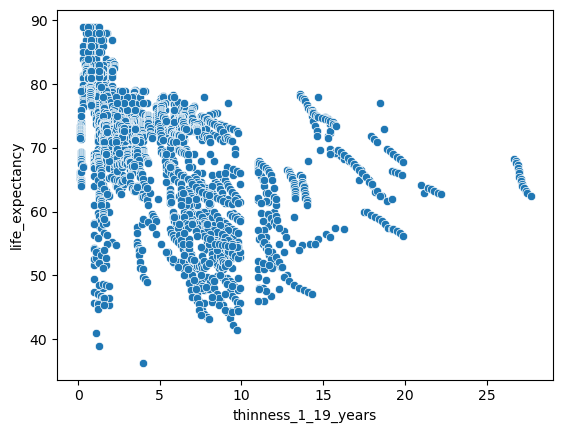

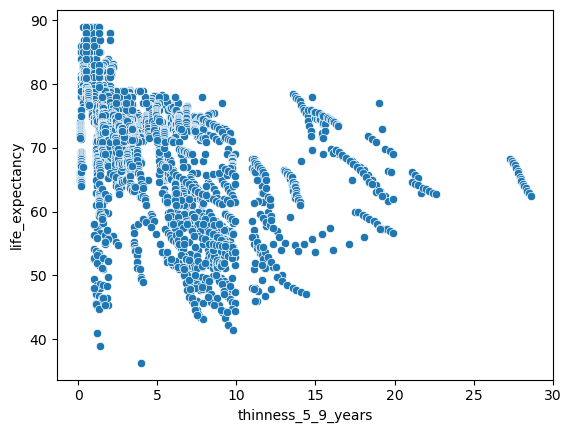

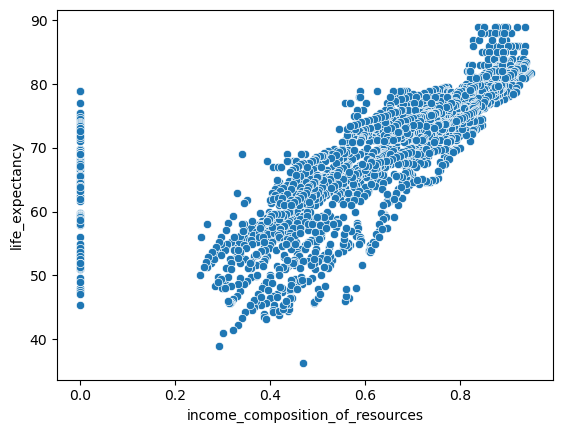

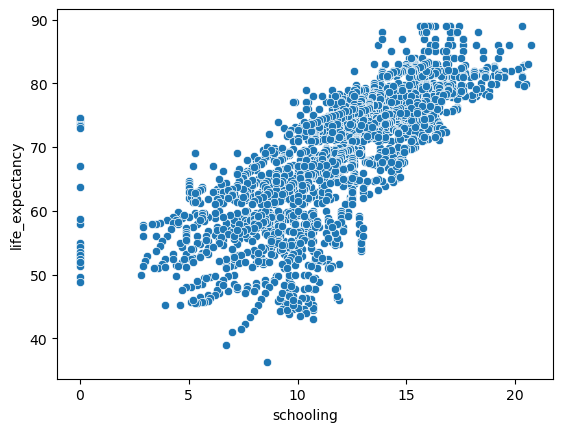

In [24]:
# Numerical Features Vs Numerical Target
for col in num_cols:
    sns.scatterplot(x=df[col], y=df['life_expectancy'])
    plt.show()

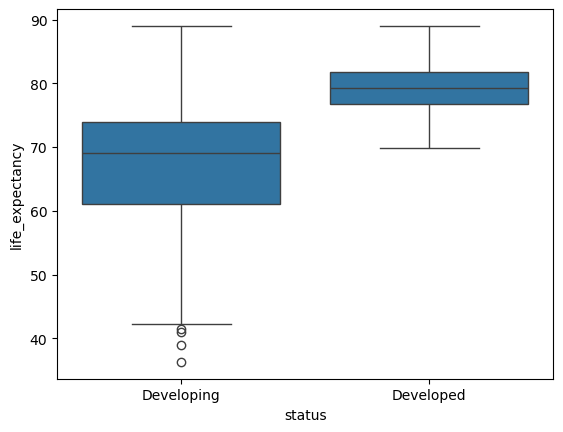

In [25]:
# Categorical features Vs Target Variable
for col in cat_cols:
    sns.boxplot(x=df[col], y=df['life_expectancy'])
    plt.show()

In [26]:
# Checking the correlation of numerical with target variable
corr_with_target = df.corr(numeric_only=True)['life_expectancy'].sort_values(ascending=False)
print(corr_with_target)

life_expectancy                    1.000000
schooling                          0.751975
income_composition_of_resources    0.724776
bmi                                0.567694
diphtheria                         0.479495
polio                              0.465556
gdp                                0.461455
alcohol                            0.404877
percentage_expenditure             0.381864
hepatitis_b                        0.256762
total_expenditure                  0.218086
year                               0.170033
population                        -0.021538
measles                           -0.157586
infant_deaths                     -0.196557
under_five_deaths                 -0.222529
thinness_5_9_years                -0.471584
thinness_1_19_years               -0.477183
hiv_aids                          -0.556556
adult_mortality                   -0.696359
Name: life_expectancy, dtype: float64


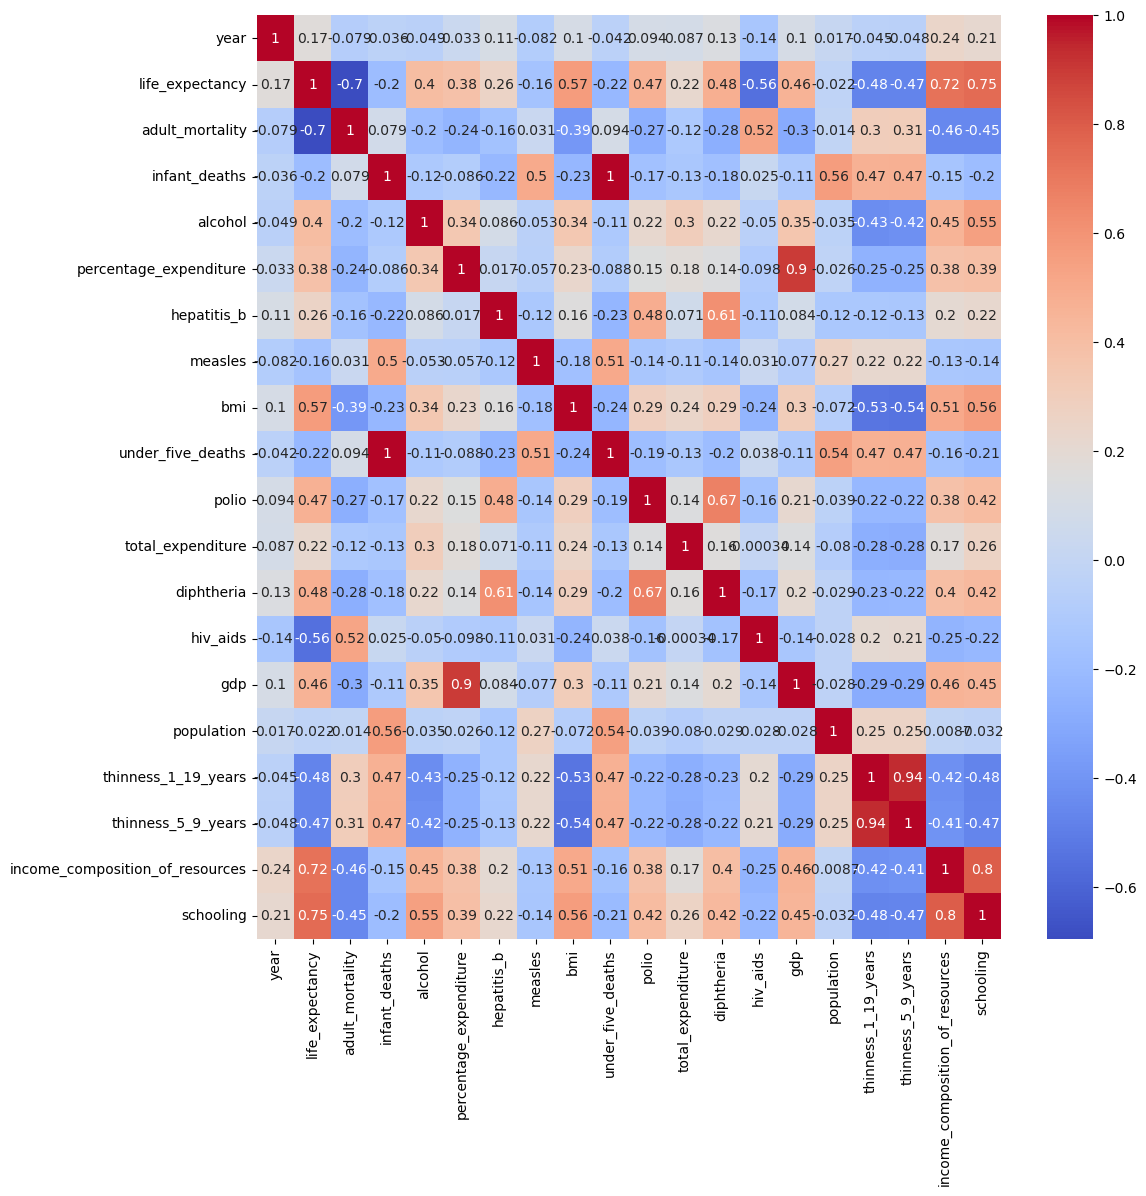

In [27]:
# Correlation Matrix
plt.figure(figsize=(12,12))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=True)
plt.show()

# <center> TrainTest Split</center>

In [28]:
X = df.drop('life_expectancy', axis=1)
y = df['life_expectancy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# <center>Baseline Model</center>

In [29]:
# Encoding categorical Variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first = True)

#Align Train and test columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [30]:
#Checking the missing vaues in training dataset
X_train.isnull().sum()

year                                 0
adult_mortality                      0
infant_deaths                        0
alcohol                            155
percentage_expenditure               0
hepatitis_b                        444
measles                              0
bmi                                 26
under_five_deaths                    0
polio                               14
total_expenditure                  182
diphtheria                          14
hiv_aids                             0
gdp                                347
population                         511
thinness_1_19_years                 26
thinness_5_9_years                  26
income_composition_of_resources    130
schooling                          130
status_Developing                    0
dtype: int64

In [31]:
# Imputing the mean on missing values for baseline model
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)

In [32]:
# Agian Checking the null
X_train_imputed.isnull().sum()

year                               0
adult_mortality                    0
infant_deaths                      0
alcohol                            0
percentage_expenditure             0
hepatitis_b                        0
measles                            0
bmi                                0
under_five_deaths                  0
polio                              0
total_expenditure                  0
diphtheria                         0
hiv_aids                           0
gdp                                0
population                         0
thinness_1_19_years                0
thinness_5_9_years                 0
income_composition_of_resources    0
schooling                          0
status_Developing                  0
dtype: int64

In [ ]:
# Creating the Baseline model

results=[]

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(),
    "GradientBoost": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor()
}

for name, model in models.items():
    
    # Train model
    model.fit(X_train_imputed, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_imputed)
    y_test_pred = model.predict(X_test_imputed)
    
    # Train metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    
    # Test metrics
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train MSE": train_mse,
        "Test MSE": test_mse
    })
    

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test R2', ascending=False)
results_df

,Model,Train R2,Test R2,Train MSE,Test MSE
5,RandomForest,0.994599,0.967861,4.952396e-01,2.780017
8,XGBoost,0.999168,0.965940,7.631694e-02,2.946129
9,GradientBoost,0.961962,0.949571,3.487656e+00,4.362100
4,DecisionTree,1.000000,0.923257,6.467177e-32,6.638225
10,AdaBoost,0.911537,0.903829,8.111091e+00,8.318765
0,Linear,0.819881,0.820603,1.651482e+01,15.517745
1,Ridge,0.819877,0.820573,1.651521e+01,15.520300
3,ElasticNet,0.811264,0.807340,1.730492e+01,16.664977
2,Lasso,0.809931,0.807148,1.742715e+01,16.681569
6,KNN,0.448809,0.084824,5.053790e+01,79.162173


In [34]:
# Calculating the Avg R2 for validation fold using cross_val_score for our baseline models

result = []

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(),
    "GradientBoost": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor()
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_imputed, y_train, cv=5, scoring='r2')
    avg_score = np.mean(scores)
    std_dev = np.std(scores)

    result.append({
        "Model": name,
        "CV Scores": scores,
        "Average Score": avg_score,
        "Standard Deviation": std_dev
    })

result = pd.DataFrame(result).sort_values(by = 'Average Score', ascending=False)
result

,Model,CV Scores,Average Score,Standard Deviation
5,RandomForest,"[0.9558972750437097, 0.9586842996502211, 0.950...",0.958177,0.004919
8,XGBoost,"[0.9576214055857863, 0.9593530735344935, 0.950...",0.957545,0.004174
9,GradientBoost,"[0.9434493692855594, 0.9376859931371365, 0.928...",0.940090,0.006518
4,DecisionTree,"[0.9121287296020147, 0.9338853719783179, 0.909...",0.917322,0.008752
10,AdaBoost,"[0.8848297213012895, 0.9004377440496836, 0.874...",0.890862,0.009762
1,Ridge,"[0.8224365208714157, 0.8095036390094914, 0.812...",0.814100,0.005845
0,Linear,"[0.8224942308431813, 0.8095452356283077, 0.812...",0.814096,0.005877
3,ElasticNet,"[0.8169961234145915, 0.7995031382931652, 0.806...",0.806638,0.007716
2,Lasso,"[0.8175202812200992, 0.7974308560315856, 0.806...",0.805580,0.008362
6,KNN,"[0.13289357197425544, 0.1323377819138325, 0.12...",0.101012,0.048271


In [35]:
# Calculating the Avg R2 for validation as well as training fold using cross_validation for our baseline models

result = []

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(),
    "GradientBoost": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor()
}

results = []

for name, model in models.items():
    cv_results = cross_validate(
        model,
        X_train_imputed,
        y_train,
        cv=5,
        scoring='r2',
        return_train_score=True
    )
    
    results.append({
        "Model": name,
        "Train R2 Mean": cv_results['train_score'].mean(),
        "Train R2 Std": cv_results['train_score'].std(),
        "Test R2 Mean": cv_results['test_score'].mean(),
        "Test R2 Std": cv_results['test_score'].std()
    })

results_df = pd.DataFrame(results).sort_values(by='Test R2 Mean', ascending=False)
results_df

,Model,Train R2 Mean,Train R2 Std,Test R2 Mean,Test R2 Std
5,RandomForest,0.993951,0.000142,0.958023,0.005636
8,XGBoost,0.999555,0.000051,0.957545,0.004174
9,GradientBoost,0.963140,0.000733,0.940071,0.006455
4,DecisionTree,1.000000,0.000000,0.913322,0.007546
10,AdaBoost,0.908640,0.002762,0.892524,0.009568
1,Ridge,0.820368,0.001566,0.814100,0.005845
0,Linear,0.820375,0.001566,0.814096,0.005877
3,ElasticNet,0.811707,0.001609,0.806638,0.007716
2,Lasso,0.810286,0.001621,0.805580,0.008362
6,KNN,0.437629,0.004270,0.101012,0.048271


# <center> Model Training & Evaluation - Preprocessing, Hyperparameter Tuning, and Cross Validation

In [ ]:
# Linear Regression Models with Preprocessing, Hyperparameter Tuning, and CrossValidation

# Import libraries
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF Function 
def remove_high_vif(df, threshold=10):
    X = df.copy()
    while True:
        vif = pd.DataFrame()
        vif['Feature'] = X.columns
        vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        max_vif = vif['VIF'].max()
        if max_vif > threshold:
            drop_feature = vif.loc[vif['VIF'] == max_vif, 'Feature'].values[0]
            X = X.drop(columns=[drop_feature])
        else:
            break
    return X

# Step 0: Keep raw data intact 
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()
y_train_raw = y_train.copy()
y_test_raw = y_test.copy()

# Step 1: Median imputation 
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_raw), columns=X_train_raw.columns)

# Step 2: Skewness correction 
skewed_cols = X_train_imputed.columns[X_train_imputed.skew().abs() > 0.5]
X_train_skewed = X_train_imputed.copy()
X_test_skewed = X_test_imputed.copy()
X_train_skewed[skewed_cols] = np.log1p(X_train_skewed[skewed_cols])
X_test_skewed[skewed_cols] = np.log1p(X_test_skewed[skewed_cols])

# Step 3: Scaling 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_skewed), columns=X_train_skewed.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_skewed), columns=X_train_skewed.columns)

# Step 4: VIF feature selection 
X_train_vif = remove_high_vif(X_train_scaled)
X_test_vif = X_test_scaled[X_train_vif.columns]

# Step 5: Define models and hyperparameter grids 
models_params = {
    "Linear": {
        "model": LinearRegression(),
        "params": {}
    },
    "Ridge": {
        "model": Ridge(),
        "params": {"regressor__alpha": [0.01, 0.1, 1, 10, 100]}
    },
    "Lasso": {
        "model": Lasso(max_iter=5000),
        "params": {"regressor__alpha": [0.001, 0.01, 0.1, 1]}
    },
    "ElasticNet": {
        "model": ElasticNet(max_iter=5000),
        "params": {
            "regressor__alpha": [0.001, 0.01, 0.1, 1],
            "regressor__l1_ratio": [0.2, 0.5, 0.7, 0.9]
        }
    }
}

# Step 6: GridSearchCV + CV evaluation 
results = []

for name, mp in models_params.items():
    print(f"Running GridSearchCV for {name}...")
    
    ttr_model = TransformedTargetRegressor(
        regressor=mp["model"],
        transformer=PowerTransformer(method='yeo-johnson')
    )
    
    grid = GridSearchCV(
        estimator=ttr_model,
        param_grid=mp["params"],
        scoring='r2',
        cv=5,
        n_jobs=1
    )
    
    # Fit GridSearchCV
    grid.fit(X_train_vif, y_train_raw)

    print(f"Best parameters for {name}: {grid.best_params_}")
    print(f"Best CV R2 for {name}: {grid.best_score_:.4f}")
    
    # Crossvalidation on best estimator
    cv_results = cross_validate(
        grid.best_estimator_,
        X_train_vif,
        y_train_raw,
        cv=5,
        scoring='r2',
        return_train_score=True
    )
    
    # Predict on test set
    y_pred_test = grid.best_estimator_.predict(X_test_vif)
    
    # Store results
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best CV R2": grid.best_score_,
        "CV Train R2 Mean": np.mean(cv_results['train_score']),
        "CV Train R2 Std": np.std(cv_results['train_score']),
        "CV Test R2 Mean": np.mean(cv_results['test_score']),
        "CV Test R2 Std": np.std(cv_results['test_score']),
        "Test R2": r2_score(y_test_raw, y_pred_test),
        "Test MSE": mean_squared_error(y_test_raw, y_pred_test)
    })

# Step 7: Display results 
results_linear_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False)
results_linear_df

Running GridSearchCV for Linear...
Best parameters for Linear: {}
Best CV R2 for Linear: 0.8108
Running GridSearchCV for Ridge...
Best parameters for Ridge: {'regressor__alpha': 100}
Best CV R2 for Ridge: 0.8143
Running GridSearchCV for Lasso...
Best parameters for Lasso: {'regressor__alpha': 0.01}
Best CV R2 for Lasso: 0.8131
Running GridSearchCV for ElasticNet...
Best parameters for ElasticNet: {'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.2}
Best CV R2 for ElasticNet: 0.8141


,Model,Best Params,Best CV R2,CV Train R2 Mean,CV Train R2 Std,CV Test R2 Mean,CV Test R2 Std,Test R2,Test MSE
3,ElasticNet,"{'regressor__alpha': 0.1, 'regressor__l1_ratio...",0.814141,0.820028,0.004263,0.814141,0.013615,0.811835,16.276144
1,Ridge,{'regressor__alpha': 100},0.814306,0.821670,0.004603,0.814306,0.014241,0.807123,16.683770
2,Lasso,{'regressor__alpha': 0.01},0.813149,0.820449,0.004665,0.813149,0.014820,0.802611,17.074047
0,Linear,{},0.810791,0.818953,0.004916,0.810791,0.015390,0.801261,17.190834


In [202]:
# ElasticNet Best parameters
results_linear_df.loc[results_linear_df["Model"]=='ElasticNet', "Best Params"].values[0]

{'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.2}

In [ ]:
# KNN & SVR with Preprocessing, Modeling with Hyperparameter Tuning and Cross Validation

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# Step 1: Copy raw train and test sets 
X_train_knn_svr = X_train.copy()
X_test_knn_svr = X_test.copy()

# Step 2: Imputation 
imputer = SimpleImputer(strategy='median')
X_train_knn_svr = pd.DataFrame(imputer.fit_transform(X_train_knn_svr), columns=X_train.columns)
X_test_knn_svr = pd.DataFrame(imputer.transform(X_test_knn_svr), columns=X_test.columns)

# Step 3: Optional skew transformation 
skewed_cols = ['infant_deaths','measles','under_five_deaths','hiv_aids',
               'population','gdp','percentage_expenditure']

X_train_knn_svr[skewed_cols] = np.log1p(X_train_knn_svr[skewed_cols])
X_test_knn_svr[skewed_cols] = np.log1p(X_test_knn_svr[skewed_cols])

# Step 4: Scaling 
scaler = StandardScaler()
X_train_knn_svr = pd.DataFrame(scaler.fit_transform(X_train_knn_svr), columns=X_train.columns)
X_test_knn_svr = pd.DataFrame(scaler.transform(X_test_knn_svr), columns=X_test.columns)

# Step 5: Define models and hyperparameter grids 
models_params = {
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "regressor__n_neighbors": [3, 5, 7, 9],
            "regressor__weights": ['uniform', 'distance'],
            "regressor__p": [1, 2]  # Manhattan=1, Euclidean=2
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "regressor__kernel": ['linear', 'rbf'],
            "regressor__C": [0.1, 1, 10, 100],
            "regressor__epsilon": [0.01, 0.1, 0.2]
        }
    }
}

# Step 6: Hyperparameter tuning + CV 
results = []

for name, mp in models_params.items():
    print(f"Running GridSearchCV for {name}...")
    
    # Wrap model in TransformedTargetRegressor for yeo-johnson target transformation
    ttr_model = TransformedTargetRegressor(
        regressor=mp["model"],
        transformer=PowerTransformer(method='yeo-johnson')
    )
    
    # GridSearchCV for hyperparameter tuning
    grid = GridSearchCV(
        estimator=ttr_model,
        param_grid=mp["params"],
        scoring='r2',
        cv=5,
        n_jobs=1
    )
    
    # Fit on training data
    grid.fit(X_train_knn_svr, y_train)
    
    print(f"Best parameters for {name}: {grid.best_params_}")
    print(f"Best CV R2 for {name}: {grid.best_score_:.4f}")
    
    # Crossvalidation on best parameters 
    best_model = grid.best_estimator_
    
    cv_results = cross_validate(
        best_model,
        X_train_knn_svr,
        y_train,
        cv=5,
        scoring='r2',
        return_train_score=True
    )
    
    # Fit on full training data and evaluate on test set
    best_model.fit(X_train_knn_svr, y_train)
    y_pred_test = best_model.predict(X_test_knn_svr)
    
    # Store results
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best CV R2": grid.best_score_,
        "CV Train R2 Mean": np.mean(cv_results['train_score']),
        "CV Train R2 Std": np.std(cv_results['train_score']),
        "CV Test R2 Mean": np.mean(cv_results['test_score']),
        "CV Test R2 Std": np.std(cv_results['test_score']),
        "Test R2": r2_score(y_test, y_pred_test),
        "Test MSE": mean_squared_error(y_test, y_pred_test)
    })

# Step 7: Convert results to DataFrame 
results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False)
results_df

Running GridSearchCV for KNN...
Best parameters for KNN: {'regressor__n_neighbors': 3, 'regressor__p': 1, 'regressor__weights': 'distance'}
Best CV R2 for KNN: 0.9466
Running GridSearchCV for SVR...
Best parameters for SVR: {'regressor__C': 10, 'regressor__epsilon': 0.01, 'regressor__kernel': 'rbf'}
Best CV R2 for SVR: 0.9338


,Model,Best Params,Best CV R2,CV Train R2 Mean,CV Train R2 Std,CV Test R2 Mean,CV Test R2 Std,Test R2,Test MSE
0,KNN,"{'regressor__n_neighbors': 3, 'regressor__p': ...",0.946603,1.000000,0.000000,0.946603,0.004471,0.956660,3.748914
1,SVR,"{'regressor__C': 10, 'regressor__epsilon': 0.0...",0.933833,0.986629,0.001075,0.933833,0.003780,0.942976,4.932557


In [204]:
# Best hyperparameter for KNN
results_df.loc[results_df["Model"]=='KNN', "Best Params"].values[0]

{'regressor__n_neighbors': 3,
 'regressor__p': 1,
 'regressor__weights': 'distance'}

In [ ]:
# Tree Based Models with Preprocessing, Hyperparameter Tuning, and CrossValidation

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

# Step 1: Copy raw train and test sets 
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

# Step 2: Imputation 
imputer = SimpleImputer(strategy='median')
X_train_tree = pd.DataFrame(imputer.fit_transform(X_train_tree), columns=X_train.columns)
X_test_tree = pd.DataFrame(imputer.transform(X_test_tree), columns=X_test.columns)

# Step 3: Define models and hyperparameter grids 
models_params_tree = {
    "DecisionTree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "regressor__max_depth": [None, 5, 10, 20],
            "regressor__min_samples_split": [2, 5, 10],
            "regressor__min_samples_leaf": [1, 2, 5]
        }
    },
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=1),
        "params": {
            "regressor__n_estimators": [100, 200],
            "regressor__max_depth": [None, 5, 10],
            "regressor__min_samples_split": [2, 5],
            "regressor__min_samples_leaf": [1, 2]
        }
    },
    "GradientBoost": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "regressor__n_estimators": [100, 200],
            "regressor__learning_rate": [0.01, 0.1],
            "regressor__max_depth": [3, 5]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42, n_jobs=1, verbosity=0),
        "params": {
            "regressor__n_estimators": [100, 200],
            "regressor__learning_rate": [0.01, 0.1],
            "regressor__max_depth": [3, 5]
        }
    },
    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=42),
        "params": {
            "regressor__n_estimators": [50, 100, 200],
            "regressor__learning_rate": [0.01, 0.1, 1]
        }
    }
}

# Step 4: GridSearchCV + Crossvalidation 
results_tree = []

for name, mp in models_params_tree.items():
    print(f"Running GridSearchCV for {name}...")
    
    # Wrap model in TransformedTargetRegressor
    ttr_model = TransformedTargetRegressor(
        regressor=mp["model"],
        transformer=PowerTransformer(method='yeo-johnson')
    )
    
    grid = GridSearchCV(
        estimator=ttr_model,
        param_grid=mp["params"],
        scoring='r2',
        cv=5,
        n_jobs=1
    )
    
    grid.fit(X_train_tree, y_train)

    print(f"Best parameters for {name}: {grid.best_params_}")
    print(f"Best CV R2 for {name}: {grid.best_score_:.4f}")

    y_pred_test = grid.predict(X_test_tree)
    
    # Crossvalidation for best parameters
    best_model = grid.best_estimator_
    cv_score = cross_validate(
        best_model,
        X_train_tree, y_train,
        cv=5, scoring='r2', return_train_score=True
    )
    
    results_tree.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best CV R2": grid.best_score_,
        "CV Train R2 Mean": cv_score['train_score'].mean(),
        "CV Train R2 Std": cv_score['train_score'].std(),
        "CV Test R2 Mean": cv_score['test_score'].mean(),
        "CV Test R2 Std": cv_score['test_score'].std(),
        "Test R2": r2_score(y_test, y_pred_test),
        "Test MSE": mean_squared_error(y_test, y_pred_test)
    })

# Step 5: Convert results to DataFrame 
results_tree_df = pd.DataFrame(results_tree).sort_values(by='Test R2', ascending=False)
results_tree_df

Running GridSearchCV for DecisionTree...
Best parameters for DecisionTree: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 2}
Best CV R2 for DecisionTree: 0.9167
Running GridSearchCV for RandomForest...
Best parameters for RandomForest: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best CV R2 for RandomForest: 0.9571
Running GridSearchCV for GradientBoost...
Best parameters for GradientBoost: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 200}
Best CV R2 for GradientBoost: 0.9571
Running GridSearchCV for XGBoost...
Best parameters for XGBoost: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 200}
Best CV R2 for XGBoost: 0.9563
Running GridSearchCV for AdaBoost...
Best parameters for AdaBoost: {'regressor__learning_rate': 0.1, 'regressor__n_estimators': 200}
Best CV R2 for Ad

,Model,Best Params,Best CV R2,CV Train R2 Mean,CV Train R2 Std,CV Test R2 Mean,CV Test R2 Std,Test R2,Test MSE
2,GradientBoost,"{'regressor__learning_rate': 0.1, 'regressor__...",0.957103,0.995918,0.000345,0.957103,0.006615,0.965441,2.989298
1,RandomForest,"{'regressor__max_depth': None, 'regressor__min...",0.957112,0.993807,0.000106,0.957112,0.005924,0.964917,3.034670
3,XGBoost,"{'regressor__learning_rate': 0.1, 'regressor__...",0.956277,0.994782,0.000337,0.956277,0.005217,0.964503,3.070511
0,DecisionTree,"{'regressor__max_depth': None, 'regressor__min...",0.916675,0.978689,0.000873,0.916675,0.010961,0.933916,5.716222
4,AdaBoost,"{'regressor__learning_rate': 0.1, 'regressor__...",0.878492,0.891743,0.004637,0.878492,0.008907,0.878503,10.509388


In [ ]:
# Voting Regressor with Preprocessing, Hyperparameter Tuning, and CrossValidation

from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# Step 1: Copy raw train and test sets 
X_train_voting = X_train.copy()
X_test_voting = X_test.copy()

# Step 2: Imputation 
imputer = SimpleImputer(strategy='median')
X_train_voting = pd.DataFrame(imputer.fit_transform(X_train_voting), columns=X_train.columns)
X_test_voting = pd.DataFrame(imputer.transform(X_test_voting), columns=X_test.columns)

# Step 3: Optional skew transformation 
skewed_cols = X_train_voting.columns[X_train_voting.skew().abs() > 0.5]
X_train_voting[skewed_cols] = np.log1p(X_train_voting[skewed_cols])
X_test_voting[skewed_cols] = np.log1p(X_test_voting[skewed_cols])

# Step 4: Scaling
scaler = StandardScaler()
X_train_voting = pd.DataFrame(scaler.fit_transform(X_train_voting), columns=X_train.columns)
X_test_voting = pd.DataFrame(scaler.transform(X_test_voting), columns=X_test.columns)

# Step 5: Define Voting Regressor and hyperparameter grid
base_models = [
    ('ridge', Ridge()),
    ('lasso', Lasso()),
    ('knn', KNeighborsRegressor()),
    ('svr', SVR()),
    ('dt', DecisionTreeRegressor())
]

voting_model = VotingRegressor(estimators=base_models)

param_grid = {
    'regressor__ridge__alpha': [0.1, 1, 10],
    'regressor__lasso__alpha': [0.01, 0.1, 1],
    'regressor__knn__n_neighbors': [3, 5, 7],
    'regressor__dt__max_depth': [None, 5, 10]
}

# Step 6: GridSearchCV + Crossvalidation
results_voting = []

ttr_model = TransformedTargetRegressor(
    regressor=voting_model,
    transformer=PowerTransformer(method='yeo-johnson')
)

grid = GridSearchCV(
    estimator=ttr_model,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=1
)

print("Running GridSearchCV for VotingRegressor...")
grid.fit(X_train_voting, y_train)

print(f"Best parameters for VotingRegressor: {grid.best_params_}")
print(f"Best CV R2 for VotingRegressor: {grid.best_score_:.4f}")

# Predict on test set
y_pred_test = grid.predict(X_test_voting)

# Crossvalidation with best parameters
best_model = grid.best_estimator_
cv_score = cross_validate(
    best_model,
    X_train_voting, y_train,
    cv=5, scoring='r2', return_train_score=True
)

results_voting.append({
    "Model": "VotingRegressor",
    "Best Params": grid.best_params_,
    "Best CV R2": grid.best_score_,
    "CV Train R2 Mean": cv_score['train_score'].mean(),
    "CV Train R2 Std": cv_score['train_score'].std(),
    "CV Test R2 Mean": cv_score['test_score'].mean(),
    "CV Test R2 Std": cv_score['test_score'].std(),
    "Test R2": r2_score(y_test, y_pred_test),
    "Test MSE": mean_squared_error(y_test, y_pred_test)
})

# Step 7: Convert results to DataFrame
results_voting_df = pd.DataFrame(results_voting)
results_voting_df

Running GridSearchCV for VotingRegressor...
Best parameters for VotingRegressor: {'regressor__dt__max_depth': 10, 'regressor__knn__n_neighbors': 3, 'regressor__lasso__alpha': 0.01, 'regressor__ridge__alpha': 0.1}
Best CV R2 for VotingRegressor: 0.9155


,Model,Best Params,Best CV R2,CV Train R2 Mean,CV Train R2 Std,CV Test R2 Mean,CV Test R2 Std,Test R2,Test MSE
0,VotingRegressor,"{'regressor__dt__max_depth': 10, 'regressor__k...",0.915538,0.94563,0.001028,0.914911,0.007311,0.919588,6.955612


In [ ]:
# Bagging Regressor with Preprocessing, Hyperparameter Tuning, and CrossValidation

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# Step 1: Copy raw data
X_train_bagging = X_train.copy()
X_test_bagging = X_test.copy()

# Step 2: Median imputation
imputer = SimpleImputer(strategy='median')
X_train_bagging = pd.DataFrame(imputer.fit_transform(X_train_bagging), columns=X_train.columns)
X_test_bagging = pd.DataFrame(imputer.transform(X_test_bagging), columns=X_test.columns)

# Step 3: Skewness correction
skewed_cols = X_train_bagging.columns[X_train_bagging.skew().abs() > 0.5]
X_train_bagging[skewed_cols] = np.log1p(X_train_bagging[skewed_cols])
X_test_bagging[skewed_cols] = np.log1p(X_test_bagging[skewed_cols])

# Step 4: Scaling
scaler = StandardScaler()
X_train_bagging = pd.DataFrame(scaler.fit_transform(X_train_bagging), columns=X_train.columns)
X_test_bagging = pd.DataFrame(scaler.transform(X_test_bagging), columns=X_test.columns)

# Step 5: Bagging Regressor with simpler hyperparameters
bag_model = BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=42)

param_grid = {
    'regressor__n_estimators': [10, 50, 100],
    'regressor__max_samples': [0.7, 0.8, 1.0],
    'regressor__max_features': [0.7, 0.8, 1.0]
    # Avoid tuning base_estimator parameters here for parallel safety
}

ttr_model = TransformedTargetRegressor(regressor=bag_model, transformer=PowerTransformer(method='yeo-johnson'))

grid = GridSearchCV(estimator=ttr_model, param_grid=param_grid, scoring='r2', cv=5, n_jobs=1)  # <n_jobs=1 for stability

print("Running GridSearchCV for BaggingRegressor...")
grid.fit(X_train_bagging, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# Test predictions
y_pred_test = grid.predict(X_test_bagging)

# Crossvalidation with best parameters
best_model = grid.best_estimator_
cv_score = cross_validate(best_model, X_train_bagging, y_train, cv=5, scoring='r2', return_train_score=True)

results_bagging = [{
    "Model": "BaggingRegressor",
    "Best Params": grid.best_params_,
    "Best CV R2": grid.best_score_,
    "CV Train R2 Mean": cv_score['train_score'].mean(),
    "CV Train R2 Std": cv_score['train_score'].std(),
    "CV Test R2 Mean": cv_score['test_score'].mean(),
    "CV Test R2 Std": cv_score['test_score'].std(),
    "Test R2": r2_score(y_test, y_pred_test),
    "Test MSE": mean_squared_error(y_test, y_pred_test)
}]

results_bagging_df = pd.DataFrame(results_bagging)
results_bagging_df

Running GridSearchCV for BaggingRegressor...
Best parameters: {'regressor__max_features': 0.8, 'regressor__max_samples': 1.0, 'regressor__n_estimators': 100}
Best CV R2: 0.9596257813241106


,Model,Best Params,Best CV R2,CV Train R2 Mean,CV Train R2 Std,CV Test R2 Mean,CV Test R2 Std,Test R2,Test MSE
0,BaggingRegressor,"{'regressor__max_features': 0.8, 'regressor__m...",0.959626,0.994215,0.00018,0.959626,0.005276,0.968391,2.734185


In [222]:
# Combining the results
result = pd.concat([results_linear_df, results_df, results_tree_df, results_bagging_df, results_voting_df],ignore_index=True)
result.to_csv("model_comparison_results.csv", index=False)
result

,Model,Best Params,Best CV R2,CV Train R2 Mean,CV Train R2 Std,CV Test R2 Mean,CV Test R2 Std,Test R2,Test MSE
0,ElasticNet,"{'regressor__alpha': 0.1, 'regressor__l1_ratio...",0.814141,0.820028,0.004263,0.814141,0.013615,0.811835,16.276144
1,Ridge,{'regressor__alpha': 100},0.814306,0.821670,0.004603,0.814306,0.014241,0.807123,16.683770
2,Lasso,{'regressor__alpha': 0.01},0.813149,0.820449,0.004665,0.813149,0.014820,0.802611,17.074047
3,Linear,{},0.810791,0.818953,0.004916,0.810791,0.015390,0.801261,17.190834
4,KNN,"{'regressor__n_neighbors': 3, 'regressor__p': ...",0.946603,1.000000,0.000000,0.946603,0.004471,0.956660,3.748914
5,SVR,"{'regressor__C': 10, 'regressor__epsilon': 0.0...",0.933833,0.986629,0.001075,0.933833,0.003780,0.942976,4.932557
6,GradientBoost,"{'regressor__learning_rate': 0.1, 'regressor__...",0.957103,0.995918,0.000345,0.957103,0.006615,0.965441,2.989298
7,RandomForest,"{'regressor__max_depth': None, 'regressor__min...",0.957112,0.993807,0.000106,0.957112,0.005924,0.964917,3.034670
8,XGBoost,"{'regressor__learning_rate': 0.1, 'regressor__...",0.956277,0.994782,0.000337,0.956277,0.005217,0.964503,3.070511
9,DecisionTree,"{'regressor__max_depth': None, 'regressor__min...",0.916675,0.978689,0.000873,0.916675,0.010961,0.933916,5.716222


# <center>Final_model</center>

In [ ]:

# Final Deployment-Ready Pipeline

import pandas as pd
import numpy as np
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score, mean_squared_error


# Step 1: Detect skewed columns

skewness = X_train.skew().abs()
skewed_cols = skewness[skewness > 0.5].index.tolist()

print("Skewed Columns:", skewed_cols)


# Step 2: Define transformers

log_transformer = FunctionTransformer(np.log1p, feature_names_out="one-to-one")

# pipeline for skewed columns
skew_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler())
])

# pipeline for normal columns
normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Step 3: Column Transformer

preprocessor = ColumnTransformer([
    ("skewed", skew_pipeline, skewed_cols),
    ("normal", normal_pipeline, [col for col in X_train.columns if col not in skewed_cols])
])


# Step 4: Bagging Model

bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    max_samples=1.0,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)


# Step 5: Full Pipeline

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", bag_model)
])


# Step 6: Target Transformation

final_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=PowerTransformer(method="yeo-johnson")
)


# Step 7: Cross Validation

cv_results = cross_validate(
    final_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    return_train_score=True
)

print("CV Train R2 Mean:", cv_results["train_score"].mean())
print("CV Test R2 Mean:", cv_results["test_score"].mean())


# Step 8: Train Final Model

final_model.fit(X_train, y_train)


# Step 9: Test Evaluation

y_pred = final_model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))


# Step 10: Actual vs Predicted

comparison_df = pd.DataFrame({
    "Actual_Life_Expectancy": y_test,
    "Predicted_Life_Expectancy": y_pred
})

print(comparison_df.head())


# Step 11: Save Model

joblib.dump(final_model, "life_expectancy_pipeline.pkl")

print("Model saved successfully.")

Skewed Columns: ['adult_mortality', 'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'under_five_deaths', 'polio', 'total_expenditure', 'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_1_19_years', 'thinness_5_9_years', 'income_composition_of_resources', 'schooling', 'status_Developing']
CV Train R2 Mean: 0.9941289492251348
CV Test R2 Mean: 0.9594765836365562
Test R2: 0.9681659261878229
Test MSE: 2.7536283582494843
      Actual_Life_Expectancy  Predicted_Life_Expectancy
2399                    56.5                  55.824863
196                     73.0                  69.500725
2316                    82.5                  82.219599
1735                    75.6                  76.292112
1102                    53.0                  53.311327
Model saved successfully.


                            Feature  Importance
12                         hiv_aids    0.395514
17  income_composition_of_resources    0.276771
1                   adult_mortality    0.159058
18                        schooling    0.034889
16               thinness_5_9_years    0.022784
8                 under_five_deaths    0.015182
7                               bmi    0.013612
3                           alcohol    0.013383
15              thinness_1_19_years    0.012378
2                     infant_deaths    0.008411
0                              year    0.008089
10                total_expenditure    0.006740
9                             polio    0.005536
13                              gdp    0.005207
4            percentage_expenditure    0.004990
14                       population    0.004642
6                           measles    0.004227
11                       diphtheria    0.003872
5                       hepatitis_b    0.002890
19                status_Developing    0

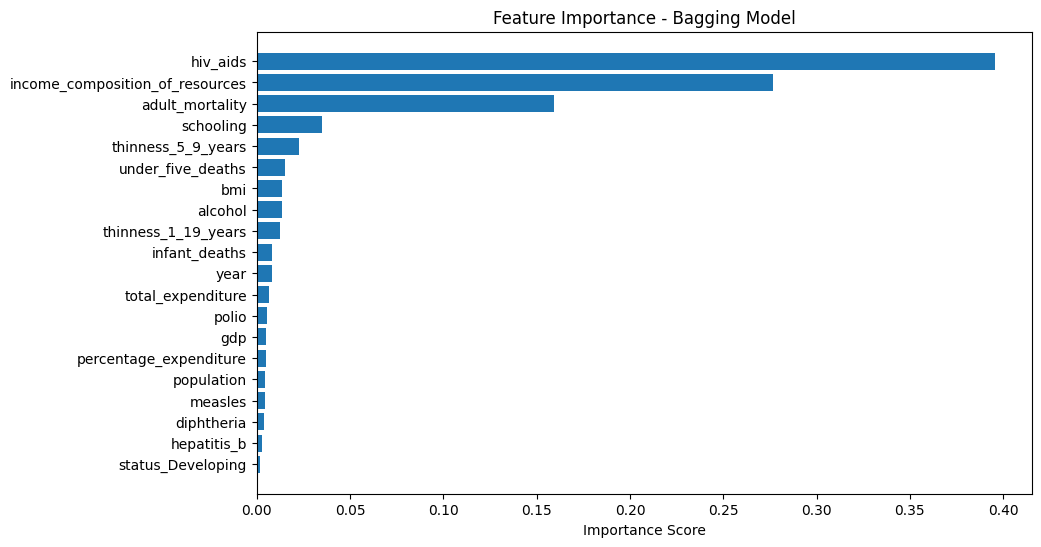

In [ ]:
# Feature Importance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extract bagging model
bag_model = ttr_model.regressor_

# Number of original features
n_features = X_train_pipe.shape[1]

# Store importance
feature_importances = np.zeros(n_features)

# Loop through trees
for tree, features in zip(bag_model.estimators_, bag_model.estimators_features_):
    
    # temporary importance
    temp = np.zeros(n_features)
    
    # assign tree importance to correct feature positions
    temp[features] = tree.feature_importances_
    
    feature_importances += temp

# Average importance
feature_importances /= len(bag_model.estimators_)

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X_train_pipe.columns,
    "Importance": feature_importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Bagging Model")
plt.xlabel("Importance Score")
plt.show()

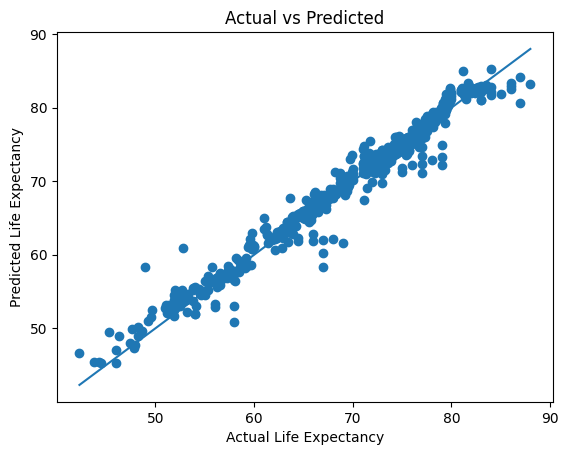

In [ ]:
# Actual Vs Predicted plot of final model

plt.scatter(y_test_pipe, y_pred_test)
plt.plot([y_test_pipe.min(), y_test_pipe.max()],
         [y_test_pipe.min(), y_test_pipe.max()])

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted")
plt.show()

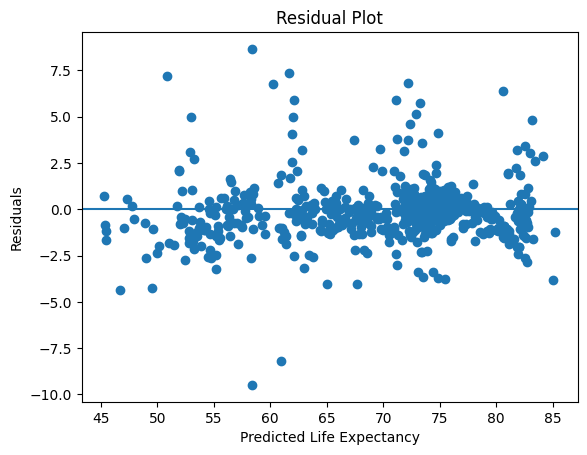

In [286]:
# Residual Analysis Plot

import matplotlib.pyplot as plt

residuals = y_test_pipe - y_pred_test

plt.scatter(y_pred_test, residuals)
plt.axhline(0)
plt.xlabel("Predicted Life Expectancy")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
#Prediction

import joblib
import pandas as pd

model = joblib.load("life_expectancy_pipeline.pkl")

sample = pd.DataFrame({
"year":[2015],
"adult_mortality":[120],
"infant_deaths":[3],
"alcohol":[7],
"percentage_expenditure":[2000],
"hepatitis_b":[95],
"measles":[0],
"bmi":[26],
"under_five_deaths":[3],
"polio":[95],
"total_expenditure":[9],
"diphtheria":[95],
"hiv_aids":[0.1],
"gdp":[20000],
"population":[2000000],
"thinness_1_19_years":[1.5],
"thinness_5_9_years":[1.6],
"income_composition_of_resources":[0.82],
"schooling":[15],
"status_Developing":[False]
})

print(model.predict(sample))

[76.75695628]
